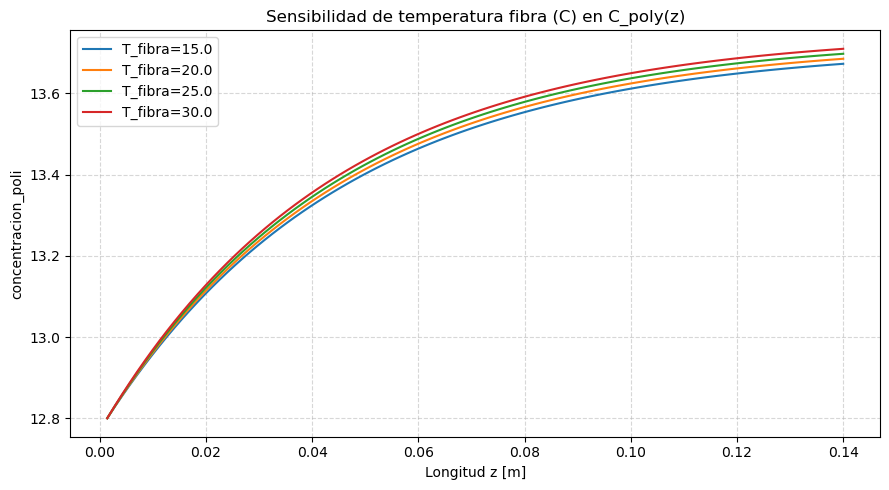

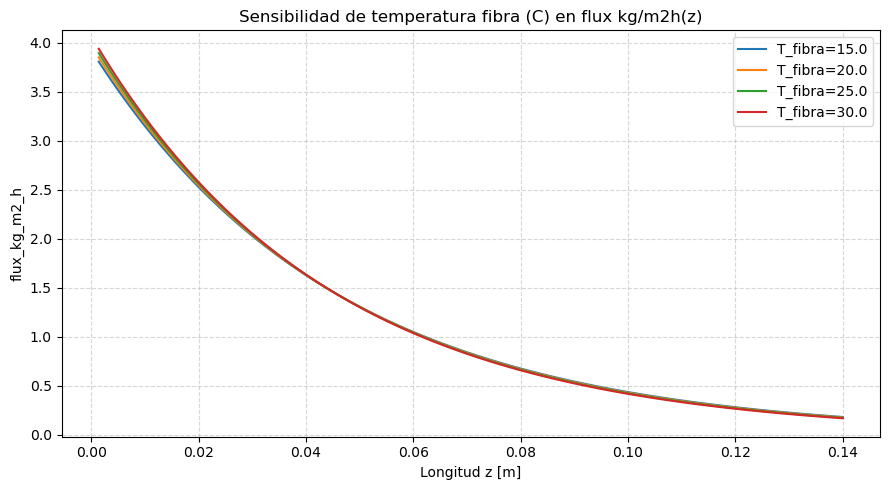

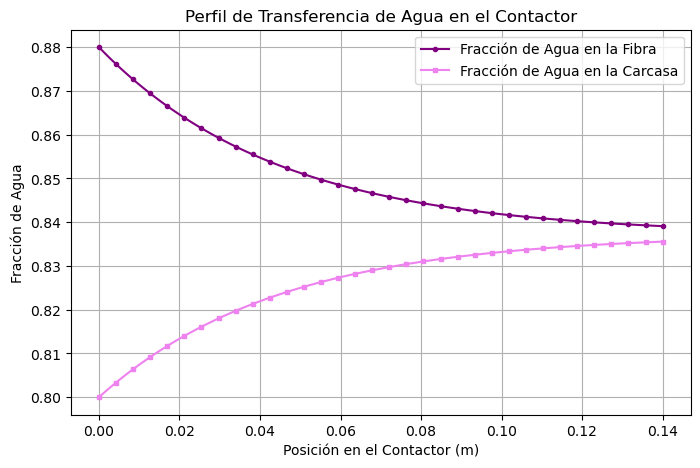

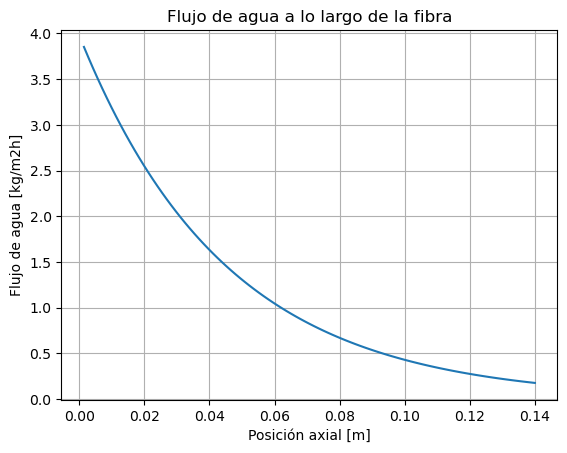

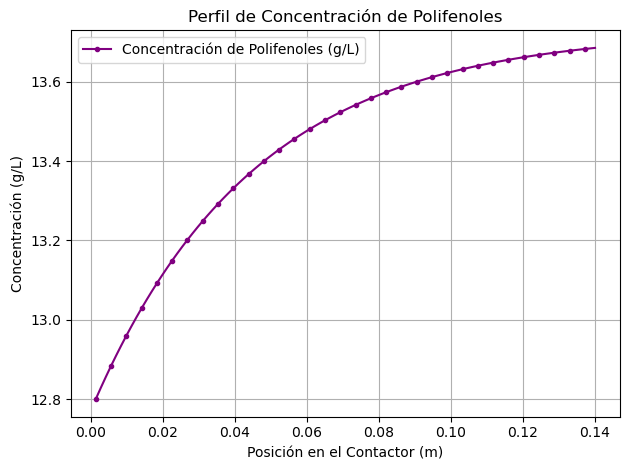

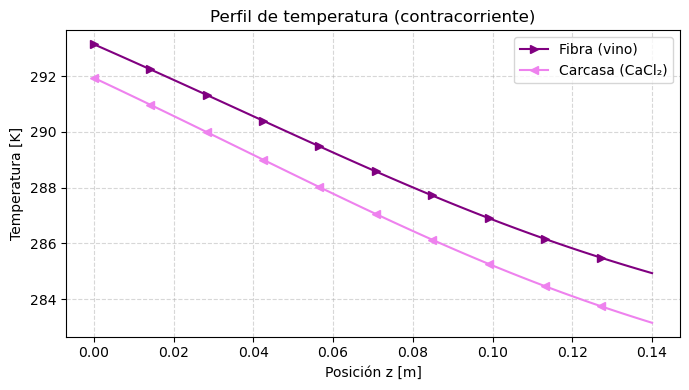

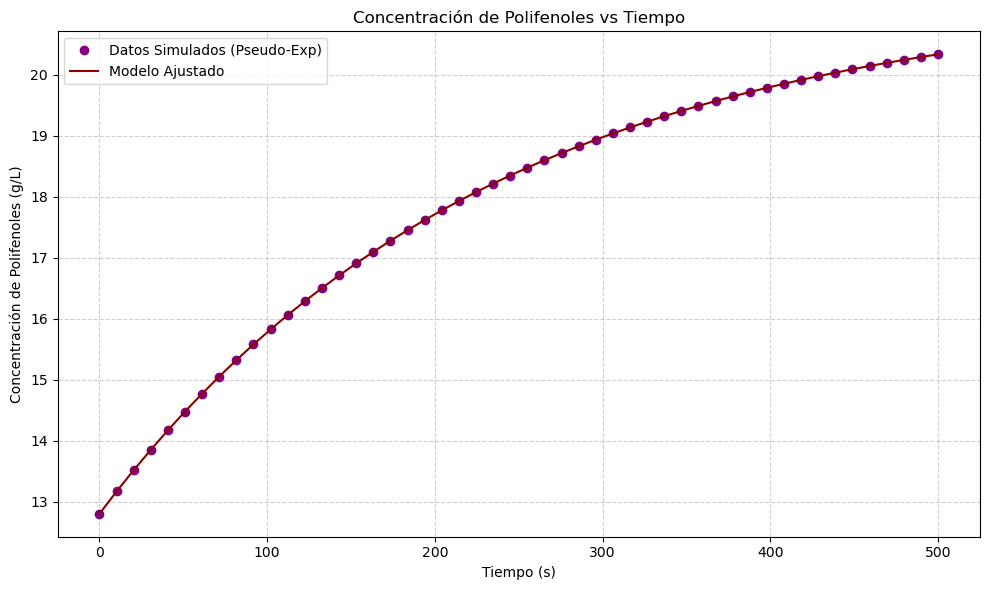

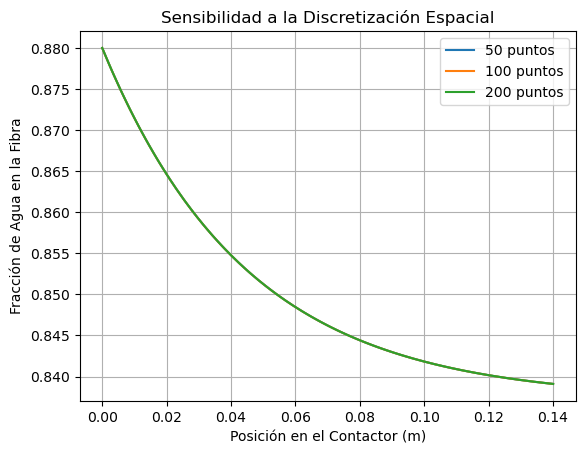

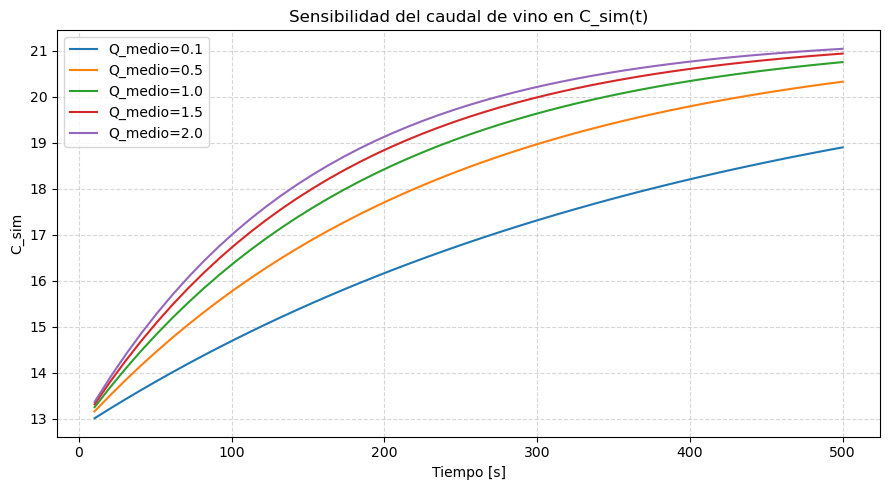

  Q_medio  flux_kg_m2_h_in  flux_kg_m2_h_out  flux_kg_m2_h_avg  m_dot_int_kg_s  delta_f_fibra  stage_cut_pct  Prod_kg_h     Re  balance_fibra_error_%  Q_mL_min
1.667e-06             2.26         0.0001976            0.2711       7.455e-05        0.04279          4.862     0.2773 0.5332                  4.547       100
8.333e-06            3.853            0.1758             1.226       0.0003461         0.0409          4.648      1.254  2.666                  1.548       500
1.667e-05            4.848            0.7031              2.18       0.0006177        0.03671          4.171       2.23  5.332                 0.9722      1000
  2.5e-05            5.545             1.276             2.938       0.0008333        0.03309           3.76      3.005  7.998                 0.7405      1500
3.333e-05              6.1             1.819             3.567        0.001012        0.03019          3.431      3.649  10.66                 0.6105      2000


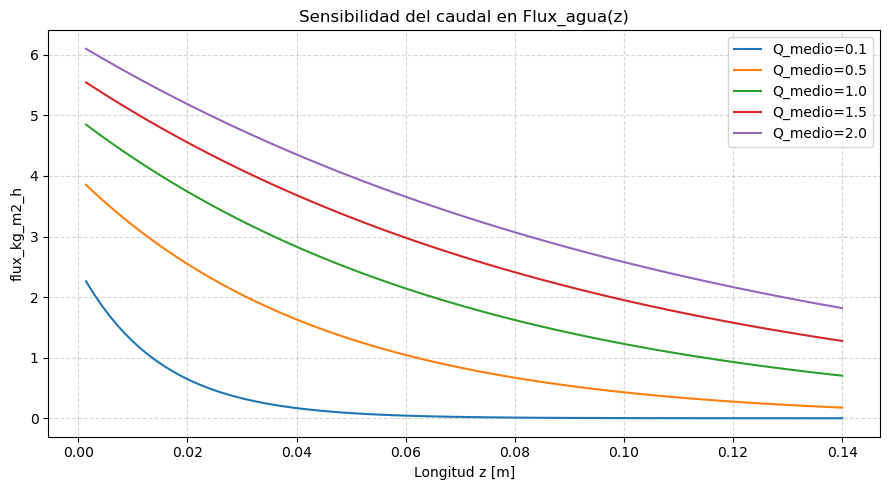

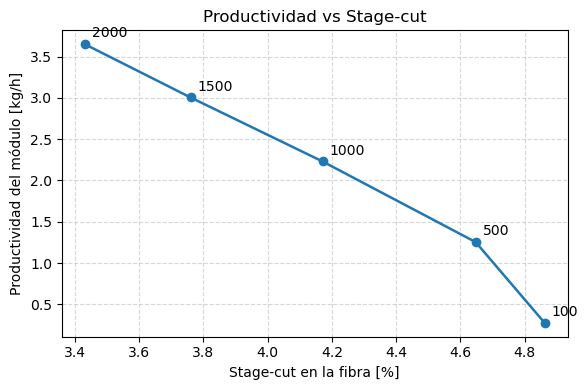

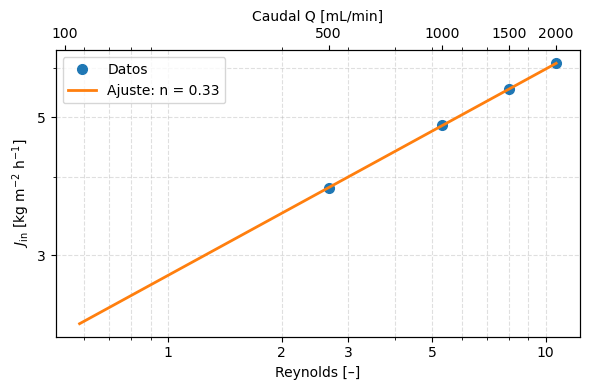

Exponente estimado n ≈ 0.33
 Q [mL/min]  Re [–]  J_in [kg m^-2 h^-1]
        100   0.533                 2.26
        500    2.67                 3.85
      1e+03    5.33                 4.85
    1.5e+03       8                 5.55
      2e+03    10.7                  6.1


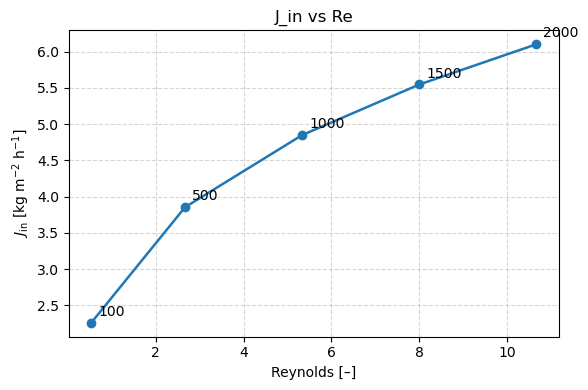

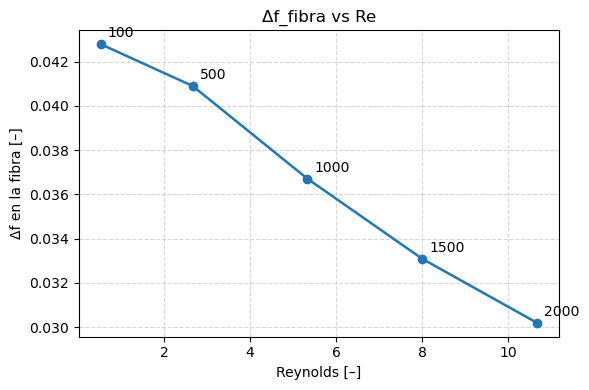

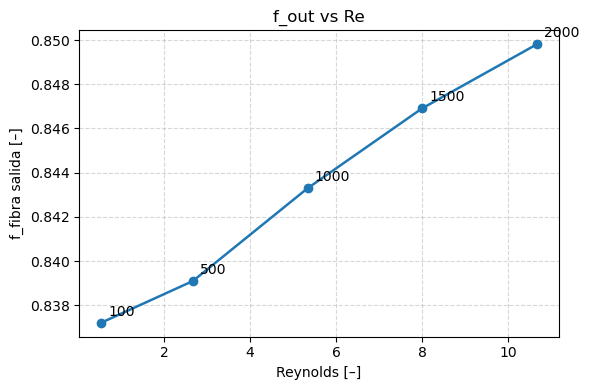

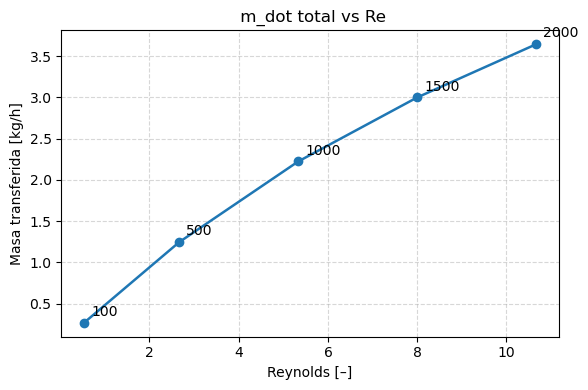

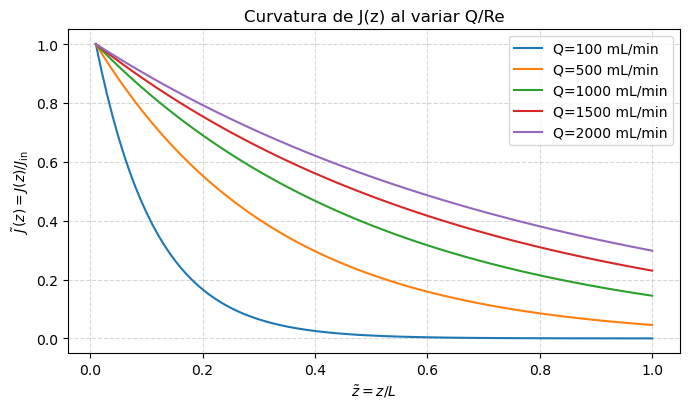

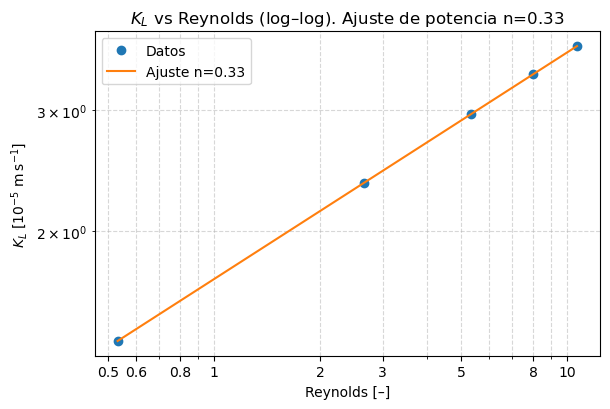

Pendiente n ≈ 0.33 (esperado ~1/3)


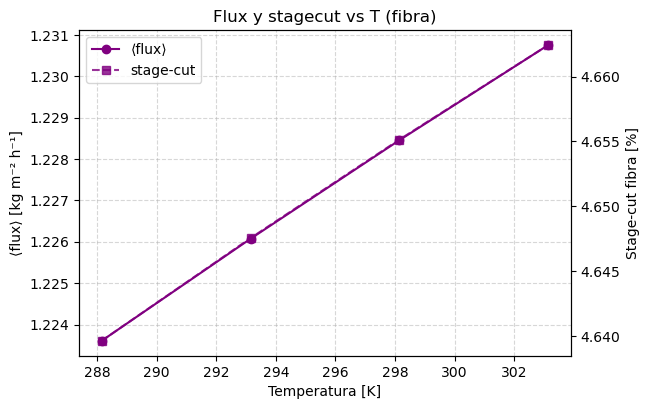

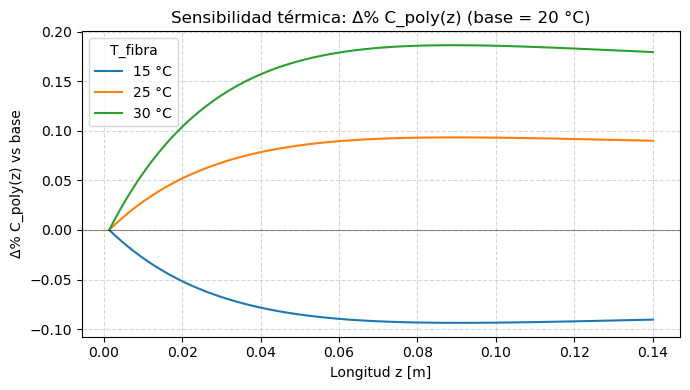

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
from scipy import stats
from scipy.integrate import solve_ivp, solve_bvp
from scipy.optimize import fsolve
from scipy.optimize import curve_fit
from numpy import trapezoid

def Parameters (inputs_fixed, lista):
    valores = lista
    ext = {k: inputs_fixed[k] for k in valores}
    return ext.values()

def interpolar_viscosidad(datos, T):
    temperaturas, viscosidades = np.array(list(datos.keys())), np.array(list(datos.values()))
    return np.interp(T, temperaturas, viscosidades)

def viscosidad_vino(inputs_fixed, fraccion_etanol=0.12):
    T = inputs_fixed["T_celsius_fibra"]
    eta_agua = interpolar_viscosidad(viscosidad_agua, T)
    eta_etanol = interpolar_viscosidad(viscosidad_etanol, T)
    return (1 - fraccion_etanol) * eta_agua + fraccion_etanol * eta_etanol

def presion_vapor_antoine(inputs_fixed):
    keys = ["T_celsius_fibra", "A", "B", "C"]
    valores= Parameters(inputs_fixed, keys)
    T, A, B, C = valores
    P_mmHg = 10 ** (A - (B / (T + C)))
    return P_mmHg *133.322

def calcular_longitud_libre_media(inputs_fixed):
    keys = ["k_B", "T_fibra", "pi", "d_vapor"]
    valores= Parameters(inputs_fixed, keys)
    k_B, T, pi, d = valores
    P_vapor = presion_vapor_antoine(inputs_fixed)
    return (k_B * T) / (np.sqrt(2) * pi * d**2 * P_vapor)

def mu_water_Pa_s_K(TK):
    TK = np.asarray(TK, dtype=float)
    TC = TK - 273.15
    return 2.414e-5 * 10.0**(247.8 / (TC + 133.15))

def Calculos(inputs_fixed):
    
    keys = ["rho", "Q_medio", "n_fibras", "D_int_fibra","D_out_fibra", "r_int_fibra", "diametro_carcasa", "pi", "L", "T_celsius_carcasa", "densidad_CaCl2"]
    valores= Parameters(inputs_fixed, keys)
    rho, Q_medio, n_fibras, D_int_fibra, D_out_fibra , r_int_fibra, diametro_carcasa, pi, L, T_celsius_carcasa, densidad_CaCl2 = valores
    P_vapor = presion_vapor_antoine(inputs_fixed)
    longitud_libre_media = calcular_longitud_libre_media(inputs_fixed)
    mu_vino = viscosidad_vino(inputs_fixed)
    mdot_fibra = rho * Q_medio
    Q_fibra = Q_medio / n_fibras
    Esp_mem = (D_out_fibra - D_int_fibra) / 2
    A_fibra = pi * (r_int_fibra ** 2)
    v_fibra = Q_fibra / A_fibra 
    A_contacto_real = n_fibras * pi * D_int_fibra * L
    A_contacto_efectiva = A_contacto_real
    A_flujo_carcasa = pi * (diametro_carcasa / 2) ** 2 
    A_flujo_fibras_totales = pi * (D_out_fibra / 2) ** 2 * n_fibras
    A_flujo_efec_car = A_flujo_carcasa - A_flujo_fibras_totales
    Perim_carcasa = pi * diametro_carcasa
    Perim_fibra_total = pi * D_out_fibra * n_fibras
    Perimetro_mojado = Perim_carcasa + Perim_fibra_total
    D_equiv = 4 * A_flujo_efec_car / Perimetro_mojado
    masa_CaCl2 = 20  # g de CaCO₃
    masa_solucion_total = 100  # g de solución total
    rho_carcasa = (masa_solucion_total / (masa_solucion_total / 1.0)) * 1000
    Q_carcasa = Q_medio
    v_carcasa = Q_carcasa / A_flujo_efec_car
    viscosidad_CaCl2 = interpolar_viscosidad(viscosidad_CaCl2_20, T_celsius_carcasa)
    mdot_carcasa = densidad_CaCl2 * Q_medio
    z = np.linspace(0, L, 100)
    return {
        "P_vapor": P_vapor,
        "longitud_libre_media": longitud_libre_media,
        "mu_vino": mu_vino,
        "mdot_fibra": mdot_fibra,
        "Esp_mem": Esp_mem,
        "v_fibra": v_fibra,
        "A_contacto_efectiva": A_contacto_efectiva,
        "D_equiv": D_equiv,
        "rho_carcasa": rho_carcasa,
        "v_carcasa": v_carcasa,
        "viscosidad_CaCl2": viscosidad_CaCl2,
        "mdot_carcasa": mdot_carcasa,
        "z" : z
    }
    
def regula_falsi(f, a, b, tol=1e-6, max_iter=100):

    fa = f(a)
    fb = f(b)

    if fa * fb > 0:
        raise ValueError("La función debe cambiar de signo en el intervalo")

    for _ in range(max_iter):
        c = b - fb * (b - a) / (fb - fa)
        fc = f(c)

        if abs(fc) < tol:
            return c
        if fa * fc < 0:
            b, fb = c, fc
        else:
            a, fa = c, fc
    return c

def difusion_efectiva(inputs_fixed):
    keys = ["phi_B", "M_B", "T_fibra", "mu_vino","V_A", "diametro_poro", "R", "M", "longitud_libre_media", "porosidad", "tortuosidad", "D_fick_gas"]
    valores= Parameters(inputs_fixed, keys)
    phi_B, M_B, T_fibra, mu_vino, V_A, diametro_poro, R, M, longitud_libre_media, porosidad, tortuosidad, D_fick_gas = valores
    
    D_fick = (7.4e-8 * (phi_B * (M_B**0.5) * T_fibra)) / (mu_vino*1000 * V_A**0.6) * 1e-4
    D_knudsen = (2/3) * diametro_poro * np.sqrt(2 * R * T_fibra / (np.pi * M))

    Kn = longitud_libre_media / diametro_poro

    if Kn > 1:
        D_base = D_knudsen
    elif Kn < 0.01:
        D_base = D_fick
    else:
        D_base = (1 / D_knudsen + 1 / D_fick_gas) ** -1
    D_efectivo = D_base * (porosidad / tortuosidad)

    return {
        "D_efectivo": D_efectivo,
        "D_fick": D_fick,
        "Kn": Kn,
        }

def difusividad_chapman(inputs_fixed):
    keys = ["T_fibra", "M_A", "M_B", "sigma_A","sigma_B", "Omega_AB"]
    valores= Parameters(inputs_fixed, keys)
    T, M_A, M_B , sigma_A, sigma_B, Omega = valores
    P_atm = 1
    M_red = 1/M_A + 1/M_B
    sigma_AB = (sigma_A + sigma_B)/2

    D_AB_cm2_s = (1.858e-3 * T**1.5 * np.sqrt(M_red)) / (P_atm * sigma_AB**2 * Omega)

    return D_AB_cm2_s * 1e-4

def N_adimensionales_fibra(inputs_fixed):
    
    keys = ["mu_vino", "rho", "D_fick", "Cp", "k", "v_fibra", "D_int_fibra", "a_fibra", "b_fibra", "L"]
    valores= Parameters(inputs_fixed, keys)
    mu_vino, rho, D_fick, Cp, k, v_fibra, D_int_fibra, a_fibra, b_fibra, L = valores
    
    Sc = mu_vino / (rho * D_fick)

    Pr = (Cp * mu_vino) / k

    Re = (rho * v_fibra * D_int_fibra) / mu_vino

    Nu = Nusselt_exp(a_fibra , b_fibra, Re, Pr, D_int_fibra, L)

    Gz_fibra = (Re * Sc * D_int_fibra) / L

    Sh = 1.62 * (Re**0.33) * (Sc**0.33) * (D_int_fibra/L) ** 0.33

    return {
        "Sc": Sc,
        "Pr": Pr,
        "Re": Re,
        "Nu": Nu,
        "Gz_fibra": Gz_fibra,
        "Sh": Sh,
        }
    
def Sherwood_carcasa(D_equiv, Frac_empaque, Re_carcasa, Sc_carcasa, L, Gz_shell): # Cálculo Sherwood carcasa
    """
    # Selector de correlación de Sherwood
    print("Seleccione el modelo de Sherwood a utilizar:")
    print("1. Prasad and Sirkar (93)")
    print("2. Wickramasinghe et al. (140)")
    print("3. Costello et al. (24)")
    print("4. Modelo (1/3)")
    print("5. Viegas et al.")
    print("6. Wu - Chen")
    print("7. Modelo empírico (0.09)")
    print("8. Modelo empírico (-0.4575)")
    print("9. Modelo empírico (1.25)")
    print("10. Modelo empírico (0.53)")
    print("11. Modelo empírico (1.45)")
    print("12. Modelo empírico (0.53-0.58)")
    print("13. Modelo empírico (1.38)")
    print("14. Modelo empírico (0.34)")
    print("15. Modelo empírico (1.25)")
    print("16. Modelo empírico (0.163+0.27)")
    print("17. Modelo empírico (0.39)")
    """
    
    Sh_shell_corr = 4

    if Sh_shell_corr == 1:
        Sh_shell = 5.8 * ((D_equiv * (1 - Frac_empaque)) / L) * (Re_carcasa ** 0.6) * (Sc_carcasa ** 0.33)
    elif Sh_shell_corr == 2:
        Sh_shell = 0.019 * Gz_shell
    elif Sh_shell_corr == 3:
        Sh_shell = 8 * (Re_carcasa * D_equiv / L) * (Sc_carcasa ** 0.33)
    elif Sh_shell_corr == 4:
        Sh_shell = 1.615 * (Re_carcasa * Sc_carcasa * (D_equiv / L)) ** (1/3)
    elif Sh_shell_corr == 5:
        Sh_shell = 8.71 * (Re_carcasa ** 0.74) * (Sc_carcasa ** 0.33) * (D_equiv / L)
    elif Sh_shell_corr == 6:
        Sh_shell = (0.3045 * Frac_empaque ** 2 - 0.3421 * Frac_empaque + 0.15) * (Re_carcasa ** 0.9) * (Sc_carcasa ** 0.33)
    elif Sh_shell_corr == 7:
        Sh_shell = 0.09 * (1 - Frac_empaque) * (Re_carcasa ** (0.8 - 0.16 * Frac_empaque)) * (Sc_carcasa ** 0.33)
    elif Sh_shell_corr == 8:
        Sh_shell = (-0.4575 * Frac_empaque ** 2 + 0.3993 * Frac_empaque - 0.0475) * (Re_carcasa ** (4.0108 * Frac_empaque ** 2 - 4.4296 * Frac_empaque + 1.5585)) * (Sc_carcasa ** 0.33)
    elif Sh_shell_corr == 9:
        Sh_shell = 1.25 * (Re_carcasa ** 0.93) * (Sc_carcasa ** 0.33) * (D_equiv / L) ** 0.93 * (1 - Frac_empaque) ** 1.79 * (1 / Frac_empaque ** 0.86)
    elif Sh_shell_corr == 10:
        Sh_shell = 0.53 * (1 - 1.1 * Frac_empaque) * ((1 - Frac_empaque) / Frac_empaque) ** -0.47 * (Re_carcasa ** 0.53) * (Sc_carcasa ** 0.33)
    elif Sh_shell_corr == 11:
        Sh_shell = 1.45 * (D_equiv * Re_carcasa * Sc_carcasa / L) ** 0.33
    elif Sh_shell_corr == 12:
        Sh_shell = (0.53 - 0.58 * Frac_empaque) * (Re_carcasa ** 0.53) * (Sc_carcasa ** 0.33)
    elif Sh_shell_corr == 13:
        Sh_shell = 1.38 * (-0.07 + 2.35 * Frac_empaque) * ((1 - Frac_empaque) * D_equiv * Re_carcasa * Sc_carcasa / (Frac_empaque * L)) ** (1/3)
    elif Sh_shell_corr == 14:
        Sh_shell = 0.34 * (Re_carcasa ** 0.67) * (Sc_carcasa ** 0.33)
    elif Sh_shell_corr == 15:
        Sh_shell = 1.25 * (D_equiv * Re_carcasa / L) ** 0.93 * (Sc_carcasa ** 0.33)
    elif Sh_shell_corr == 16:
        Sh_shell = (0.163 + 0.27 * Frac_empaque) * (Gz_shell ** 0.6)
    elif Sh_shell_corr == 17:
        Sh_shell = 0.39 * (Re_carcasa ** 0.59) * (Sc_carcasa ** 0.33)
    else:
        print("Número de correlación inválido. Usando modelo estándar (Gawronski 2000).")
        Sh_shell = 8.71 * (Re_carcasa ** 0.74) * (Sc_carcasa ** 0.33) * (D_equiv / L)
    Sh_carcasa = Sh_shell
    return Sh_carcasa

def Nusselt_exp(a, b, Re, Pr, d, L):
    Nu = a * (Re**b) * (Pr**(1/3))*((d/L)**(1/3))
    return Nu

def Nusselt_exp_carcasa(a, b, Re, Pr, d, L):
    Nu_car = a * (Re**b) * (Pr**(1/3))*(d/L)
    return Nu_car

def N_adimensionales_carcasa(inputs_fixed):
    keys = ["rho_carcasa", "v_carcasa", "D_equiv", "viscosidad_CaCl2", "calor_especifico_CaCl2", "k_carcasa", "a_carcasa", "b_carcasa", "L", "D_fick", "n_fibras", "D_out_fibra", "diametro_carcasa"]
    valores= Parameters(inputs_fixed, keys)
    rho, v, D, mu, Cp, k, a, b, L, D_fick, n, D_out_fibra, d_carcasa = valores

    Re_carcasa = (rho * v * D) / mu

    Pr_carcasa = (Cp * mu) / k

    Nu_carcasa = Nusselt_exp_carcasa(a, b, Re_carcasa, Pr_carcasa, D, L)

    Sc_carcasa = mu / (rho * D_fick)

    Gz_shell = Re_carcasa * Sc_carcasa * D / L

    Frac_empaque = n * (D_out_fibra / d_carcasa) ** 2

    Sh_carcasa = Sherwood_carcasa(D, Frac_empaque, Re_carcasa, Sc_carcasa, L, Gz_shell)

    return {
        "Re_carcasa": Re_carcasa,
        "Pr_carcasa": Pr_carcasa,
        "Nu_carcasa": Nu_carcasa,
        "Sc_carcasa": Sc_carcasa,
        "Gz_shell": Gz_shell,
        "Frac_empaque": Frac_empaque,
        "Sh_carcasa": Sh_carcasa
        }
    
def K_transferencia_masa(inputs_fixed):
    
    keys = ["Sh", "Sh_carcasa", "D_fick", "D_int_fibra", "porosidad", "D_AB", "tortuosidad", "Esp_mem", "D_equiv"]
    valores= Parameters(inputs_fixed, keys)
    Sh, Sh_carcasa, D_fick, D_int_fibra, poro, D_AB, epsilon, espesor, D_equiv = valores
    
    K_L = (Sh * D_fick) / D_int_fibra
    K_M = (poro * D_AB) / (epsilon * espesor)
    K_carcasa = (Sh_carcasa * D_fick) / D_equiv
    K_global = 1.0 / (1.0/K_L + 1.0/K_M + 1.0/K_carcasa)

    return {
        "K_L": K_L,
        "K_M": K_M,
        "K_carcasa": K_carcasa,
        "K_global": K_global
    }
    
def flujo_transferencia_agua(f_up, f_down, K):
    rho   = float(inputs_fixed.get("rho", 1000.0))
    MW    = float(inputs_fixed.get("M", 0.018015))
    return K * (rho / MW) * (f_up - f_down)

def Perfil_fracciones_agua(L, N, f_in_fibra, f_in_carcasa, Q):
    global inputs_fixed
    A_tot   = float(inputs_fixed.get("A_contacto_efectiva", 1.0))
    MW_H2O  = float(inputs_fixed.get("M", 0.018015))
    rho_f   = float(inputs_fixed.get("rho", 1000.0))
    rho_s   = float(inputs_fixed.get("densidad_CaCl2", 1150.0))
    Q_f     = float(inputs_fixed.get("Q_medio", Q))
    Q_s     = float(inputs_fixed.get("Q_medio", Q))
    K_global  = float(inputs_fixed.get("K_global"))

    z  = np.linspace(0.0, L, int(N))
    dz = z[1] - z[0]
    A_seg = A_tot * (dz / max(L, 1e-12))

    f_fibra   = np.zeros_like(z)
    f_carcasa = np.zeros_like(z)
    J         = np.zeros_like(z)
    C_int     = np.zeros_like(z)

    f_fibra[0]   = float(f_in_fibra)
    f_carcasa[0] = float(f_in_carcasa)

    for i in range(1, len(z)):
        fF = f_fibra[i-1]
        fS = f_carcasa[i-1]
        K_L   = float(inputs_fixed["K_L"])
        K_M   = float(inputs_fixed["K_M"])
        K_S   = float(inputs_fixed["K_carcasa"])

        def balance(Cint):
            J_f = K_L * (rho_f / MW_H2O) * (fF - Cint)
            J_s = K_S * (rho_s / MW_H2O) * (Cint - fS)
    
            return J_f - J_s

        a, b = (min(fF, fS), max(fF, fS))
        try:
            Cstar = regula_falsi(balance, a, b)
        except Exception:
            Cstar = 0.5 * (fF + fS)

        C_int[i] = Cstar
        J[i] = K_L * (rho_f / MW_H2O) * (fF - Cstar)

        m_dot = J[i] * MW_H2O * A_seg

        df_f = -(m_dot) / max(rho_f * Q_f, 1e-16)
        df_s = +(m_dot) / max(rho_s * Q_s, 1e-16)

        f_fibra[i]   = float(np.clip(fF + df_f, 0.0, 1.0))
        f_carcasa[i] = float(np.clip(fS + df_s, 0.0, 1.0))
        
    C_int[0] = C_int[1] if len(z) > 1 else f_fibra[0]
    J[0]     = J[1]     if len(z) > 1 else 0.0

    flux_kg_m2_h = J * MW_H2O * 3600.0
    
    return {
        "f_fibra": f_fibra,
        "f_carcasa": f_carcasa,
        "flux_agua": J,
        "flux_kg_m2_h": flux_kg_m2_h,
    }
    
def X_polifenoles(flux_agua, C_inicial, rho, X_etanol = 0.12):
    X_agua = flux_agua 
    X_polifenoles = 1 - X_agua - X_etanol

    fraccion_inicial = C_inicial / rho
    concentracion_poli = X_polifenoles * (C_inicial / fraccion_inicial)

    factor = fraccion_inicial / X_polifenoles[0]
    X_polifenoles_escalado = X_polifenoles * factor

    concentracion_poli = X_polifenoles_escalado * rho
    return {
        "X_polifenoles_escalado": X_polifenoles_escalado,
        "concentracion_poli": concentracion_poli,
    }
    
def Sensibilidad_discretizacion(L, z, f_fibra):
    N_puntos_test = [50, 100, 200]
    for n in N_puntos_test:
        z_test = np.linspace(0, L, n)
        f_fibra_test = np.interp(z_test, z, f_fibra)
        plt.plot(z_test, f_fibra_test, label=f"{n} puntos")

    plt.xlabel("Posición en el Contactor (m)")
    plt.ylabel("Fracción de Agua en la Fibra")
    plt.title("Sensibilidad a la Discretización Espacial")
    plt.legend()
    plt.grid()
    plt.show()
    
def modelo_exponencial(t, C_inicial, C_max, k):
    return C_inicial + (C_max - C_inicial) * (1 - np.exp(-k * t))

def simular_contactores(inputs_fixed, K_L=None, K_M=None, K_carcasa=None, A_contacto_efectiva=None, k_sim=None):


    keys = ["t","C_inicial", "V_vino", "C0_agua_vino", "C_CaCl2", "V_CaCl2", "K_L", "K_M", "K_carcasa", "A_contacto_efectiva"]
    valores= Parameters(inputs_fixed, keys)
    t, C_inicial, V_vino, C0_agua_vino, C_CaCl2, V_CaCl2, K_L, K_M, K_carcasa, A_contacto_efectiva = valores

    k_sim=None

    agua_inicial_vino = C0_agua_vino * V_vino
    agua_inicial_CaCl2 = C_CaCl2 * V_CaCl2
    V_transferido_total = (agua_inicial_vino - agua_inicial_CaCl2) / (1 - C_CaCl2)
    V_transferido_total = min(V_transferido_total, V_vino * 0.9)
    C_max = (C_inicial * V_vino) / (V_vino - V_transferido_total)
    
    if k_sim is None:
        assert all(x is not None for x in [K_L, K_M, K_carcasa, A_contacto_efectiva]), \
            "Faltan K_L, K_M, K_carcasa o A_contacto_efectiva para calcular k_sim"
        K_total = 1.0 / (1.0/K_L + 1.0/K_M + 1.0/K_carcasa)
        V_vino_m3 = V_vino/ 1000.0
        k_sim = (K_total * A_contacto_efectiva) / V_vino_m3

    C_sim = modelo_exponencial(t, C_inicial, C_max, k_sim)
    C_pred = C_sim

    return {
        "C_max": C_max,
        "C_sim": C_sim,
        "C_pred": C_pred,
        "k_sim": k_sim,
        "V_transferido_total": V_transferido_total
    }
    
def h_transferencia_calor(inputs_fixed):
    keys = ["Nu", "k", "D_int_fibra", "Esp_mem", "Nu_carcasa", "k_carcasa", "D_equiv", "k_vapor", "Kn", "porosidad", "tortuosidad"]
    valores= Parameters(inputs_fixed, keys)
    Nu, k, D_int_fibra, Esp_mem, Nu_carcasa, k_carcasa, D_equiv, k_vapor, Kn, porosidad, tortuosidad = valores
    
    h_fibra_conv = (Nu * k) / D_int_fibra 
    h_f = 1 / ((1 / h_fibra_conv) + (Esp_mem / 0.15))

    h_carcasa = Nu_carcasa * k_carcasa / D_equiv

    k_gas = k_vapor * (1 + (inputs_fixed["k_gas_coef"] * Kn) / (1 + Kn))

    k_efectiva = k_gas * (porosidad / tortuosidad)
    h_membrana = k_efectiva / Esp_mem  
    return {
        "h_f": h_f,
        "h_carcasa": h_carcasa,
        "h_membrana": h_membrana,
        "k_efectiva": k_efectiva
    }

def ecuacion_transferencia_calor(z, T):
    h_f   = float(inputs_fixed["h_f"])
    h_s   = float(inputs_fixed["h_carcasa"])
    k_eff = float(inputs_fixed["k_efectiva"])
    d_mem = float(inputs_fixed["Esp_mem"])
    A_tot = float(inputs_fixed["A_contacto_efectiva"])
    L     = float(inputs_fixed["L"])
    A_per_L = A_tot / max(L, 1e-12)

    mdot_f = float(inputs_fixed["mdot_fibra"]);   Cp_f = float(inputs_fixed["Cp"])
    mdot_s = float(inputs_fixed["mdot_carcasa"]); Cp_s = float(inputs_fixed["calor_especifico_CaCl2"])

    Tf, Ts = T

    a_f = float(inputs_fixed.get("a_fibra",   1/3))
    b_f = float(inputs_fixed.get("b_fibra",   1/3))
    a_s = float(inputs_fixed.get("a_carcasa", 1/3))
    b_s = float(inputs_fixed.get("b_carcasa", 1/3))
    exp_f = a_f - b_f
    exp_s = a_s - b_s

    mu_f_ref = float(inputs_fixed["mu_f_ref"])
    mu_s_ref = float(inputs_fixed["mu_s_ref"])
    mu_f_loc = mu_water_Pa_s_K(Tf)
    mu_s_loc = mu_water_Pa_s_K(Ts)

    mu_f_loc = np.maximum(mu_f_loc, 1e-12)
    mu_s_loc = np.maximum(mu_s_loc, 1e-12)
    s_f = (mu_f_ref / mu_f_loc)**exp_f
    s_s = (mu_s_ref / mu_s_loc)**exp_s

    h_f_loc = h_f * s_f
    h_s_loc = h_s * s_s

    denom = 1.0/np.maximum(h_f_loc, 1e-12) + d_mem/max(k_eff,1e-12) + 1.0/np.maximum(h_s_loc, 1e-12)
    U = 1.0 / denom

    mfCp = mdot_f * Cp_f
    msCp = mdot_s * Cp_s
    dTf_dz = -(U * A_per_L) / max(mfCp, 1e-12) * (Tf - Ts)
    dTs_dz = -(U * A_per_L) / max(msCp, 1e-12) * (Tf - Ts)

    return np.vstack((dTf_dz, dTs_dz))

def condiciones_frontera(ya, yb):

    Tf_in = float(inputs_fixed["T_fibra"]) 
    Ts_in = float(inputs_fixed["T_carcasa"])
    return np.array([
        ya[0] - Tf_in,
        yb[1] - Ts_in,
    ])
    
def Perfil_temperatura():
    z= inputs_fixed["z"]
    z, T_carcasa, T_fibra, N_puntos = Parameters(inputs_fixed, ["z", "T_carcasa", "T_fibra", "N_puntos"])
    T_guess = np.zeros((2, N_puntos))
    T_guess[0, :] = T_fibra
    T_guess[1, :] = np.linspace(T_fibra, T_carcasa, N_puntos)

    solucion = solve_bvp(ecuacion_transferencia_calor, condiciones_frontera, z, T_guess)


    T_fibra_vals = solucion.y[0]
    T_carcasa_vals = solucion.y[1]
    
    return {
        "T_fibra_vals": T_fibra_vals,
        "T_carcasa_vals": T_carcasa_vals,
        "solucion": solucion
    }
    
def Run_model():

    inputs_fixed.update(Calculos(inputs_fixed))
    inputs_fixed["D_AB"] = difusividad_chapman(inputs_fixed)
    inputs_fixed.update(difusion_efectiva(inputs_fixed))

    inputs_fixed.update(N_adimensionales_fibra(inputs_fixed))
    inputs_fixed.update(N_adimensionales_carcasa(inputs_fixed))

    inputs_fixed.update(K_transferencia_masa(inputs_fixed))

    inputs_fixed.update(h_transferencia_calor(inputs_fixed))
    
    z, t, N_puntos = Parameters(inputs_fixed, ["z", "t", "N_puntos"])

    res = {}
    res1 = Perfil_fracciones_agua(L=inputs_fixed["L"], N= N_puntos, f_in_fibra=0.88, f_in_carcasa=0.80, Q=inputs_fixed["Q_medio"])
    res.update(res1)
    
    z      = inputs_fixed["z"]
    J      = res["flux_agua"]
    MW     = float(inputs_fixed.get("M", 0.018015))
    A_tot  = float(inputs_fixed["A_contacto_efectiva"])
    L      = float(inputs_fixed["L"])      
    Q_f    = float(inputs_fixed.get("Q_medio"))       
    rho_f  = float(inputs_fixed["rho"])  

    dz    = np.diff(z)
    J_mid = 0.5 * (J[1:] + J[:-1]) 
    m_dot_int = MW * (A_tot / L) * np.sum(J_mid * dz)

    m_dot_f   = rho_f * Q_f * (res["f_fibra"][0] - res["f_fibra"][-1])

    balance_err_f = (m_dot_int - m_dot_f) / max(1e-12, abs(m_dot_f))
    res["balance_fibra_error_pct"] = 100 * balance_err_f

    Q_s    = float(inputs_fixed.get("Q_medio"))               
    rho_s  = float(inputs_fixed.get("densidad_CaCl2", 1150.0))
    m_dot_s = rho_s * Q_s * (res["f_carcasa"][-1] - res["f_carcasa"][0])
    balance_err_s = (m_dot_int - m_dot_s) / max(1e-12, abs(m_dot_s))
    res["balance_carcasa_error_pct"] = 100 * balance_err_s
    
    res2 = X_polifenoles(res["flux_agua"], inputs_fixed["C_inicial"], inputs_fixed["rho"])
    res.update(res2)

    res["flux_promedio"] = np.mean(res["flux_agua"])
    res["flux_promedio_kg"] = np.mean(res["flux_kg_m2_h"])
    res3 = simular_contactores(inputs_fixed, k_sim=None)
    res.update(res3)
    
    inputs_fixed["mu_f_ref"] = float(mu_water_Pa_s_K(inputs_fixed["T_fibra"]))
    inputs_fixed["mu_s_ref"] = float(mu_water_Pa_s_K(inputs_fixed["T_carcasa"]))

    for k, v in [("a_fibra", 1/3), ("b_fibra", 1/3), ("a_carcasa", 1/3), ("b_carcasa", 1/3)]:
        inputs_fixed.setdefault(k, v)
    
    res4 = Perfil_temperatura()
    res.update(res4)
    
    return res

def sensitivity_plot(param_name, param_values, output_key, axis, title=None):

    global inputs_fixed
    backup = copy.deepcopy(inputs_fixed)
    
    if axis == "t":
        x = np.array(inputs_fixed["t"])
        xlabel = "Tiempo [s]"
    elif axis == "z":
        x = np.array(inputs_fixed["z"])
        xlabel = "Longitud z [m]"
    else:
        raise ValueError("axis debe ser 't' o 'z'")
    
    plt.figure(figsize=(9,5))
    for val in param_values:
        inputs_fixed[param_name] = val
        res = Run_model()
        y = np.array(res[output_key])
        if param_name == "Q_medio":
            val_L_min = val * 1e3 * 60
            plt.plot(x[1:], y[1:], label=f"{param_name}={val_L_min:.1f}")
        elif param_name == "T_fibra":
            val_c = val - 273.15
            plt.plot(x[1:], y[1:], label=f"{param_name}={val_c}")
        else:
            plt.plot(x[1:], y[1:], label=f"{param_name}={val}")
    
    plt.xlabel(xlabel)
    plt.ylabel(output_key)
    plt.title(title if title else f"Sensibilidad: {param_name} → {output_key}")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    inputs_fixed.clear()
    inputs_fixed.update(backup)
    
def sensitivity_summary_table(param_name, param_values, output_key, axis):

    global inputs_fixed, Run_model
    backup = copy.deepcopy(inputs_fixed)
    rows = []

    for val in param_values:
        inputs_fixed[param_name] = val
        res = Run_model()

        x = np.asarray(inputs_fixed["t"] if axis=="t" else inputs_fixed["z"])
        y = np.asarray(res[output_key], dtype=float)
        y_in, y_out, y_avg = float(y[0]), float(y[-1]), float(np.mean(y))

        A_tot = float(inputs_fixed.get("A_contacto_efectiva", 1.0))
        L     = float(inputs_fixed.get("L", 1.0))
        MW    = float(inputs_fixed.get("M", 0.018015))

        m_dot_int = None
        if axis=="z" and output_key in ("flux_agua","flux_kg_m2_h"):
            dz    = np.diff(x)
            y_mid = 0.5*(y[1:]+y[:-1])
            m_dot_int = (MW*(A_tot/L)*np.sum(y_mid*dz)) if output_key=="flux_agua" else ((A_tot/L)*np.sum(y_mid*dz)/3600.0)

        f_in = float(res["f_fibra"][0]) if "f_fibra" in res else np.nan
        df_f = float(res["f_fibra"][0]-res["f_fibra"][-1]) if "f_fibra" in res else np.nan
        stage_cut_pct = 100.0*df_f/f_in if f_in>0 else np.nan

        Prod_kg_h = (y_avg*A_tot) if output_key=="flux_kg_m2_h" else (y_avg*MW*3600.0*A_tot if output_key=="flux_agua" else np.nan)

        rows.append({
            param_name: val,
            f"{output_key}_in":  y_in,
            f"{output_key}_out": y_out,
            f"{output_key}_avg": y_avg,
            "m_dot_int_kg_s":    m_dot_int,
            "delta_f_fibra":     df_f,
            "stage_cut_pct":     stage_cut_pct,
            "Prod_kg_h":         Prod_kg_h,
            "Re":                float(inputs_fixed.get("Re", np.nan)),
            "balance_fibra_error_%": float(res.get("balance_fibra_error_pct", np.nan)),
        })

    inputs_fixed.clear(); inputs_fixed.update(backup)
    return pd.DataFrame(rows)

def sensitivity_run_and_plot(param_name, param_values, output_key="flux_kg_m2_h", axis="z", title=None):

    df = sensitivity_summary_table(param_name, param_values, output_key, axis)
    if param_name == "Q_medio" and "Q_medio" in df.columns:
        df["Q_mL_min"] = df["Q_medio"].astype(float) * 1e6 * 60.0
    print(df.to_string(index=False, float_format=lambda x: f"{x:.4g}"))

    try:
        sensitivity_plot(param_name, param_values, output_key, axis,title or f"Sensibilidad: {param_name} → {output_key}")
    except NameError:
        pass

    label_col = "Q_mL_min" if ("Q_mL_min" in df.columns) else (param_name if param_name in df.columns else None)
    
    plot_tradeoff(df, label_col="Q_mL_min" if "Q_mL_min" in df.columns else None)
    plt.show()

    if "Re" in df.columns and df["Re"].notna().any():
        x = df["Re"].astype(float).values
        y = df[f"{output_key}_in"].astype(float).values

        coef = np.polyfit(np.log(x), np.log(y), 1)
        n, a = coef[0], float(np.exp(coef[1]))
        xx = np.linspace(x.min(), x.max(), 200)
        yy = a * xx**n

        fig, ax = plt.subplots(figsize=(6, 4))
        ax.loglog(x[1:], y[1:], "o", markersize=7, label="Datos")
        ax.loglog(xx[1:], yy[1:], "-", linewidth=2, label=f"Ajuste: n = {n:.2f}")

        ax.set_xlabel("Reynolds [–]")
        ax.set_ylabel(r"$J_{\mathrm{in}}$ [kg m$^{-2}$ h$^{-1}$]" if output_key=="flux_kg_m2_h" else r"$J_{\mathrm{in}}$")
        ax.grid(True, which="both", linestyle="--", alpha=0.4)
        ax.legend()
        from matplotlib.ticker import LogLocator, FuncFormatter, NullFormatter
        ax.xaxis.set_major_locator(LogLocator(base=10, subs=(1.0, 2.0, 3.0, 5.0)))
        ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1.0, 2.0, 3.0, 5.0)))
        ax.xaxis.set_minor_formatter(NullFormatter())
        ax.yaxis.set_minor_formatter(NullFormatter())
        ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
        ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
        ax2 = ax.twiny()
        ax2.set_xscale('log')
        ax2.set_xlim(ax.get_xlim())               
        ax2.set_xticks(x)                           
        ax2.set_xticklabels(df["Q_mL_min"].astype(int).tolist())
        ax2.set_xlabel("Caudal Q [mL/min]")
        fig.tight_layout()
        plt.show()
        print(f"Exponente estimado n ≈ {n:.2f}")
        print(
        df[["Q_mL_min","Re","flux_kg_m2_h_in"]].rename(columns={"Q_mL_min":"Q [mL/min]", "Re":"Re [–]", "flux_kg_m2_h_in":"J_in [kg m^-2 h^-1]"}).to_string(index=False, float_format=lambda v: f"{v:.3g}")
)
    else:
        print("[AVISO] No hay 'Re' en la tabla. Omito J_in vs Re.")
    
    if "Re" in df.columns and df["Re"].notna().any():
        f_in = float(inputs_fixed.get("f_in_fibra", 0.88))
        f_out = f_in - df["delta_f_fibra"].astype(float)

        plt.figure(figsize=(6,4))
        plt.plot(df["Re"], df[f"{output_key}_in"], "o-", linewidth=1.8)
        if "Q_mL_min" in df.columns:
            for xi, yi, qlab in zip(df["Re"], df[f"{output_key}_in"], df["Q_mL_min"].astype(int)):
                plt.annotate(f"{qlab}", (xi, yi), xytext=(5,5), textcoords="offset points")
        plt.xlabel("Reynolds [–]")
        plt.ylabel(r"$J_{\mathrm{in}}$ [kg m$^{-2}$ h$^{-1}$]" if output_key=="flux_kg_m2_h" else r"$J_{\mathrm{in}}$")
        plt.title("J_in vs Re")
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.tight_layout(); plt.show()

        plt.figure(figsize=(6,4))
        plt.plot(df["Re"], df["delta_f_fibra"], "o-", linewidth=1.8)
        if "Q_mL_min" in df.columns:
            for xi, yi, qlab in zip(df["Re"], df["delta_f_fibra"], df["Q_mL_min"].astype(int)):
                plt.annotate(f"{qlab}", (xi, yi), xytext=(5,5), textcoords="offset points")
        plt.xlabel("Reynolds [–]"); plt.ylabel("Δf en la fibra [–]")
        plt.title("Δf_fibra vs Re")
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.tight_layout(); plt.show()

        plt.figure(figsize=(6,4))
        plt.plot(df["Re"], f_out, "o-", linewidth=1.8)
        if "Q_mL_min" in df.columns:
            for xi, yi, qlab in zip(df["Re"], f_out, df["Q_mL_min"].astype(int)):
                plt.annotate(f"{qlab}", (xi, yi), xytext=(5,5), textcoords="offset points")
        plt.xlabel("Reynolds [–]"); plt.ylabel("f_fibra salida [–]")
        plt.title("f_out vs Re")
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.tight_layout(); plt.show()

        if "m_dot_int_kg_s" in df.columns:
            plt.figure(figsize=(6,4))
            plt.plot(df["Re"], df["m_dot_int_kg_s"]*3600.0, "o-", linewidth=1.8)
            if "Q_mL_min" in df.columns:
                for xi, yi, qlab in zip(df["Re"], df["m_dot_int_kg_s"]*3600.0, df["Q_mL_min"].astype(int)):
                    plt.annotate(f"{qlab}", (xi, yi), xytext=(5,5), textcoords="offset points")
            plt.xlabel("Reynolds [–]"); plt.ylabel("Masa transferida [kg/h]")
            plt.title(" m_dot total vs Re")
            plt.grid(True, linestyle="--", alpha=0.5)
            plt.tight_layout(); plt.show()

    return df

def plot_tradeoff(df, label_col=None):

    x = df["stage_cut_pct"].astype(float).values
    y = df["Prod_kg_h"].astype(float).values

    fig, ax = plt.subplots(figsize=(6.0, 4.0))
    ax.plot(x, y, marker="o", linewidth=1.8, markersize=6)
    if label_col and (label_col in df.columns):
        for _, r in df.iterrows():
            lab = f'{r[label_col]:.0f}' if "mL" in label_col else f'{r[label_col]:.3g}'
            ax.annotate(lab, (r["stage_cut_pct"], r["Prod_kg_h"]),
                        xytext=(5,5), textcoords="offset points")

    ax.set_xlabel("Stage-cut en la fibra [%]")
    ax.set_ylabel("Productividad del módulo [kg/h]")
    ax.set_title("Productividad vs Stage-cut")
    ax.grid(True, which="both", linestyle="--", alpha=0.5)
    fig.tight_layout()
    return fig, ax

def sensitivity_plot_normalized(param_name, param_values, *, usar_flux="flux_kg_m2_h", titulo=None):

    import copy, numpy as np, matplotlib.pyplot as plt
    global inputs_fixed, Run_model

    backup = copy.deepcopy(inputs_fixed)
    plt.figure(figsize=(7,4.2))

    for val in param_values:
        inputs_fixed[param_name] = val
        res = Run_model()
        z   = np.asarray(inputs_fixed["z"], float)
        L   = float(inputs_fixed["L"])
        J   = np.asarray(res[usar_flux], float)

        z_t  = z / L
        J_t  = J / max(J[0], 1e-16) 

        if param_name == "Q_medio":
            lab = f"Q={val*1e6*60:.0f} mL/min"
        else:
            lab = f"{param_name}={val:g}"

        plt.plot(z_t[1:], J_t[1:], label=lab)

    plt.xlabel(r"$\tilde z = z/L$")
    plt.ylabel(r"$\tilde J(z) = J(z)/J_{\mathrm{in}}$")
    plt.title(titulo or "Perfiles normalizados (curvatura)")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

    inputs_fixed.clear(); inputs_fixed.update(backup)
    
def plot_KL_vs_Re_simple(param_name, param_values):
    global inputs_fixed, Run_model
    backup = copy.deepcopy(inputs_fixed)

    Re_list, KL_list = [], []
    for val in param_values:
        inputs_fixed[param_name] = val
        Run_model()
        Re_list.append(float(inputs_fixed.get("Re", np.nan)))
        KL_list.append(float(inputs_fixed.get("K_L", np.nan)))

    inputs_fixed.clear(); inputs_fixed.update(backup)

    Re = np.asarray(Re_list, float); KL = np.asarray(KL_list, float)
    mask = np.isfinite(Re) & np.isfinite(KL); Re, KL = Re[mask], KL[mask]

    coef = np.polyfit(np.log(Re), np.log(KL), 1)
    n, c = coef[0], float(np.exp(coef[1]))
    xx = np.logspace(np.log10(Re.min()), np.log10(Re.max()), 200)
    yy = c * xx**n

    from matplotlib.ticker import FuncFormatter

    scale = 1e5 
    KL_plot  = KL * scale
    yy_plot  = yy * scale

    fig, ax = plt.subplots(figsize=(6.2, 4.2))
    ax.set_xscale("log")
    ax.set_yscale("log") 
    ax.plot(Re, KL_plot, "o", label="Datos")
    ax.plot(xx, yy_plot, "-", label=f"Ajuste n={n:.2f}")

    candidates = np.array([0.5, 0.6, 0.8, 1, 2, 3, 5, 8, 10, 15, 20, 30])
    ticks_x = [t for t in candidates if Re.min()*0.9 <= t <= Re.max()*1.1]
    if ticks_x: ax.set_xticks(ticks_x)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v:g}"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v:g}"))

    ax.set_xlabel("Reynolds [–]")
    ax.set_ylabel(r"$K_L\ [10^{-5}\ \mathrm{m\,s^{-1}}]$")
    ax.set_title(f"$K_L$ vs Reynolds (log–log). Ajuste de potencia n={n:.2f}")
    ax.grid(True, which="both", linestyle="--", alpha=0.5)
    ax.legend()
    plt.tight_layout(); plt.show()

    print(f"Pendiente n ≈ {n:.2f} (esperado ~1/3)")

def sensitivity_T_both_table(T_values, output_key="flux_kg_m2_h"):

    global inputs_fixed, Run_model

    backup = copy.deepcopy(inputs_fixed)
    rows = []
    for T in T_values:
        inputs_fixed["T_fibra"]   = float(T+273.15)
        inputs_fixed["T_carcasa"] = float(T+273.15)
        res = Run_model()

        A_tot = float(inputs_fixed.get("A_contacto_efectiva", 1.0))
        y     = np.asarray(res[output_key], float)
        y_in, y_avg = float(y[0]), float(np.mean(y))

        f_in = float(res["f_fibra"][0]); f_out = float(res["f_fibra"][-1])
        stage = 100.0 * (f_in - f_out) / max(f_in, 1e-16)
        Prod_kg_h = y_avg * A_tot if output_key=="flux_kg_m2_h" else y_avg*float(inputs_fixed.get("M",0.018015))*3600.0*A_tot

        rows.append({
            "T_C": float(T),
            f"{output_key}_in":  y_in,
            f"{output_key}_avg": y_avg,
            "stage_cut_pct":     stage,
            "Prod_kg_h":         Prod_kg_h,
            "Re":                float(inputs_fixed.get("Re", np.nan)),
            "K_L":               float(inputs_fixed.get("K_L", np.nan)),
            "K_carcasa":         float(inputs_fixed.get("K_carcasa", np.nan)),
        })

    inputs_fixed.clear(); inputs_fixed.update(backup)
    return pd.DataFrame(rows)

def sensitivity_T_both_plots(T_values, output_key="flux_kg_m2_h"):

    global inputs_fixed, Run_model

    dfT = sensitivity_T_both_table(T_values, output_key=output_key)
    print(dfT.to_string(index=False, float_format=lambda v: f"{v:.4g}"))

    plt.figure(figsize=(6,4))
    plt.plot(dfT["T_C"], dfT[f"{output_key}_in"], "o-")
    plt.xlabel("Temperatura [°C]"); plt.ylabel(r"$J_{\mathrm{in}}$ [kg m$^{-2}$ h$^{-1}$]")
    plt.grid(True, linestyle="--", alpha=0.5); plt.tight_layout(); plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(dfT["T_C"], dfT["stage_cut_pct"], "o-")
    plt.xlabel("Temperatura [°C]"); plt.ylabel("Stage-cut en la fibra [%]")
    plt.grid(True, linestyle="--", alpha=0.5); plt.tight_layout(); plt.show()

    backup = inputs_fixed.copy()
    plt.figure(figsize=(7,4.2))
    for T in T_values:
        inputs_fixed["T_fibra"]   = float(T)
        inputs_fixed["T_carcasa"] = float(T)
        res = Run_model()
        z = np.asarray(inputs_fixed["z"], float); L = float(inputs_fixed["L"])
        J = np.asarray(res[output_key], float)
        z_t = z / L; J_t = J / max(J[0], 1e-16)
        plt.plot(z_t, J_t, label=f"T={T:g} °C")
    plt.xlabel(r"$\tilde z = z/L$"); plt.ylabel(r"$\tilde J(z) = J/J_{\mathrm{in}}$")
    plt.title("Curvatura de J(z) al variar la temperatura")
    plt.grid(True, linestyle="--", alpha=0.5); plt.legend(); plt.tight_layout(); plt.show()
    inputs_fixed.clear(); inputs_fixed.update(backup)

    return dfT

def plot_T_perfiles(res, unidades="K"):
    z  = inputs_fixed["z"]
    Tf = res["T_fibra_vals"]; Ts = res["T_carcasa_vals"]

    plt.figure(figsize=(7,4))
    
    plt.plot(z, Tf, label="Fibra (vino)", marker = ">", color = "purple", markevery = 10)
    plt.plot(z, Ts, label="Carcasa (CaCl₂)", marker = "<", color = "violet", markevery = 10)
    plt.xlabel("Posición z [m]"); plt.ylabel("Temperatura [K]")
    plt.title("Perfil de temperatura (contracorriente)")
    plt.grid(True, ls="--", alpha=0.5); plt.legend(); plt.tight_layout(); plt.show()
    
def plot_fracciones_agua(res):
    z = inputs_fixed["z"]
    plt.figure(figsize=(8,5))
    plt.plot(z, res["f_fibra"], label="Fracción de Agua en la Fibra", marker="o", markersize = 3, markevery = 3, color= "purple")
    plt.plot(z, res["f_carcasa"], label="Fracción de Agua en la Carcasa", marker="s", markersize = 3, markevery = 3, color= "violet")
    plt.xlabel("Posición en el Contactor (m)")
    plt.ylabel("Fracción de Agua")
    plt.title("Perfil de Transferencia de Agua en el Contactor")
    plt.legend()
    plt.grid()
    plt.show()
    
def plot_flux_agua(res):
    z = inputs_fixed["z"]
    plt.plot(z[1:], res["flux_kg_m2_h"][1:])
    plt.xlabel("Posición axial [m]")
    plt.ylabel("Flujo de agua [kg/m2h]")
    plt.title("Flujo de agua a lo largo de la fibra")
    plt.grid(True)
    plt.show()
    
def plot_c_poly(res):
    z = inputs_fixed["z"]
    plt.plot(z[1:], res["concentracion_poli"][1:], marker='o', label="Concentración de Polifenoles (g/L)", color = "purple", markersize = 3, markevery = 3)
    plt.xlabel("Posición en el Contactor (m)")
    plt.ylabel("Concentración (g/L)")
    plt.title("Perfil de Concentración de Polifenoles")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
def plot_c_sim_t(res):
    
    t = inputs_fixed["t"]
    plt.figure(figsize=(10, 6))
    plt.plot(t, res["C_sim"], 'o', label='Datos Simulados (Pseudo-Exp)', color = "purple")
    plt.plot(t, res["C_pred"], '-', color='darkred', label='Modelo Ajustado')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Concentración de Polifenoles (g/L)')
    plt.title('Concentración de Polifenoles vs Tiempo')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
def plot_fluxavg_stagecut_vs_T(T_values, side="carcasa", Titulo = "Flux y stagecut vs T (carcasa)"):
    global inputs_fixed, Run_model
    backup = copy.deepcopy(inputs_fixed)

    T_vals = []; Javg = []; SC = []
    for T in T_values:
        T = float(T)
        if side == "fibra":
            inputs_fixed["T_fibra"] = T
        elif side == "carcasa":
            inputs_fixed["T_carcasa"] = T
        elif side == "ambos":
            inputs_fixed["T_fibra"] = T
            inputs_fixed["T_carcasa"] = T
        else:
            raise ValueError("side debe ser 'fibra', 'carcasa' o 'ambos'.")

        res = Run_model()
        Javg.append(float(np.mean(np.asarray(res["flux_kg_m2_h"], float))))
        f = np.asarray(res["f_fibra"], float)
        SC.append(100.0 * (f[0] - f[-1]) / max(1e-12, f[0]))
        T_vals.append(T)

    fig, ax1 = plt.subplots(figsize=(6.6,4))
    ax2 = ax1.twinx()
    ax1.plot(T_vals, Javg, "o-", label="⟨flux⟩", color="purple")
    ax2.plot(T_vals, SC,   "s--", label="stage-cut", alpha=0.8, color= "purple")

    ax1.set_xlabel("Temperatura [K]")
    ax1.set_ylabel("⟨flux⟩ [kg m⁻² h⁻¹]")
    ax2.set_ylabel("Stage-cut fibra [%]")

    ax1.grid(True, ls="--", alpha=0.5)
    fig.tight_layout()

    l1, _ = ax1.get_legend_handles_labels()
    l2, _ = ax2.get_legend_handles_labels()
    ax1.legend(l1+l2, ["⟨flux⟩","stage-cut"], loc="best")
    plt.title(Titulo)
    plt.show()

    inputs_fixed.clear(); inputs_fixed.update(backup)
    
def plots(res):

    valores_K = [15+273.15, 20+273.15, 25+273.15, 30+273.15]
    sensitivity_plot(
        param_name="T_fibra",
        param_values=valores_K,
        output_key="concentracion_poli",
        axis = "z",
        title="Sensibilidad de temperatura fibra (C) en C_poly(z)"
    )
    sensitivity_plot(
        param_name="T_fibra",
        param_values=valores_K,
        output_key="flux_kg_m2_h",
        axis = "z",
        title="Sensibilidad de temperatura fibra (C) en flux kg/m2h(z)"
    )

    plot_fracciones_agua(res)
    plot_flux_agua(res)
    plot_c_poly(res)
    plot_T_perfiles(res, unidades="K")
    plot_c_sim_t(res)
    Sensibilidad_discretizacion(inputs_fixed["L"], inputs_fixed["z"], res["f_fibra"])

    valores_vino = [0.1/1000/60, 0.5/1000/60, 1.0/1000/60, 1.5/1000/60, 2.0/1000/60]  # ejemplo en m3/s

    sensitivity_plot(
        param_name="Q_medio",
        param_values=valores_vino,
        output_key="C_sim",
        axis = "t",
        title="Sensibilidad del caudal de vino en C_sim(t)"
    )

    df_q = sensitivity_run_and_plot(
        param_name="Q_medio",
        param_values=valores_vino,
        output_key="flux_kg_m2_h",
        axis="z",
        title="Sensibilidad del caudal en Flux_agua(z)"
    )

    sensitivity_plot_normalized("Q_medio", valores_vino, titulo="Curvatura de J(z) al variar Q/Re")
    plot_KL_vs_Re_simple("Q_medio", valores_vino)
    
    plot_fluxavg_stagecut_vs_T(valores_K, side="fibra", Titulo= "Flux y stagecut vs T (fibra)")

def diagnostico_resistencias():

    L   = float(inputs_fixed["L"])
    N   = int(inputs_fixed.get("N_fibras", 9690))


    d_i = float(inputs_fixed.get("d_i",
            inputs_fixed.get("diametro_interno_fibra",
            inputs_fixed.get("D_int_fibra", 240e-6)))) 
    d_o = float(inputs_fixed.get("d_o",
            inputs_fixed.get("diametro_externo_fibra",
            inputs_fixed.get("D_ext_fibra", 310e-6))))


    A_i = np.pi * d_i * L * N  
    A_o = np.pi * d_o * L * N 
    A_rep = A_o   


    h_f   = float(inputs_fixed["h_f"])            
    h_s   = float(inputs_fixed["h_carcasa"])      
    k_eff = float(inputs_fixed["k_efectiva"])  


    ln_do_di = np.log(max(d_o/d_i, 1.0 + 1e-12))
    G_i  = h_f * A_i
    G_m  = (2.0*np.pi*k_eff*L*N) / ln_do_di
    G_o  = h_s * A_o

    R_i = 1.0 / max(G_i, 1e-30)
    R_m = 1.0 / max(G_m, 1e-30)
    R_o = 1.0 / max(G_o, 1e-30)
    R_tot = R_i + R_m + R_o
    U_global = (1.0 / R_tot) / A_rep

    frac_i = R_i / R_tot
    frac_m = R_m / R_tot
    frac_o = R_o / R_tot

    print("\n=== DIAGNÓSTICO TÉRMICO (por módulo) ===")
    print(f"A_i={A_i:.4e} m², A_o={A_o:.4e} m², N={N}, L={L:.3f} m")
    print(f"h_f={h_f:.3e} W/m²/K, h_s={h_s:.3e} W/m²/K, k_eff={k_eff:.3e} W/m/K")
    print(f"R_i={R_i:.3e} K/W, R_m={R_m:.3e} K/W, R_o={R_o:.3e} K/W, R_tot={R_tot:.3e} K/W")
    print(f"U_global(ref A_o) = {U_global:.3e} W/m²/K")
    print(f"Aportes térmicos: fibra={100*frac_i:.1f}%, membrana={100*frac_m:.1f}%, carcasa={100*frac_o:.1f}%")

    K_L = float(inputs_fixed["K_L"])  
    K_M = float(inputs_fixed["K_M"]) 
    K_S = float(inputs_fixed["K_carcasa"])

    R_L = 1.0 / max(K_L, 1e-30)
    R_M = 1.0 / max(K_M, 1e-30)
    R_S = 1.0 / max(K_S, 1e-30)
    R_tot_m = R_L + R_M + R_S

    K_global = 1.0 / R_tot_m      
    phi_L = R_L / R_tot_m
    phi_M = R_M / R_tot_m
    phi_S = R_S / R_tot_m

    print("\n=== DIAGNÓSTICO DE MASA (coeficientes K en m/s) ===")
    print(f"K_L={K_L:.3e}, K_M={K_M:.3e}, K_carcasa={K_S:.3e}  -->  K_global={K_global:.3e} m/s")
    print(f"Aportes de resistencia: L={100*phi_L:.1f}%, M={100*phi_M:.1f}%, carcasa={100*phi_S:.1f}%")

    return {
        "termico": {
            "R_i": R_i, "R_m": R_m, "R_o": R_o, "R_tot": R_tot,
            "U_global": U_global,
            "frac_i": frac_i, "frac_m": frac_m, "frac_o": frac_o,
            "A_i": A_i, "A_o": A_o, "N": N, "L": L
        },
        "masa": {
            "K_L": K_L, "K_M": K_M, "K_S": K_S, "K_global": K_global,
            "phi_L": phi_L, "phi_M": phi_M, "phi_S": phi_S
        }
    }

def plot_T_Cpoly_pct(T_listK, baseK=293.15):

    backup = copy.deepcopy(inputs_fixed)

    z = np.asarray(inputs_fixed["z"], float)

    inputs_fixed["T_fibra"] = float(baseK)
    res_base = Run_model()
    Cref = np.asarray(res_base["concentracion_poli"], float)

    plt.figure(figsize=(7,4))
    for T in T_listK:
        T = float(T)
        if abs(T - baseK) < 1e-9:
            continue 
        inputs_fixed["T_fibra"] = T
        r = Run_model()
        C = np.asarray(r["concentracion_poli"], float)
        dperc = 100.0 * (C - Cref) / (Cref + 1e-12)
        plt.plot(z[1:], dperc[1:], label=f"{T-273.15:.0f} °C")

    plt.axhline(0, lw=0.8, color="k", alpha=0.4)
    plt.xlabel("Longitud z [m]")
    plt.ylabel("Δ% C_poly(z) vs base")
    plt.title(f"Sensibilidad térmica: Δ% C_poly(z) (base = {baseK-273.15:.0f} °C)")
    plt.legend(title="T_fibra"); plt.grid(True, ls="--", alpha=0.5)
    plt.tight_layout(); plt.show()

    inputs_fixed.clear(); inputs_fixed.update(backup)

viscosidad_agua = {
    0: 1.792 / 1000, 10: 1.308 / 1000, 20: 1.002 / 1000,
    30: 0.797 / 1000, 40: 0.653 / 1000, 50: 0.547 / 1000, 60: 0.467 / 1000
}

viscosidad_etanol = {
    0: 1.824 / 1000, 10: 1.518 / 1000, 20: 1.200 / 1000,
    30: 0.947 / 1000, 40: 0.773 / 1000, 50: 0.653 / 1000, 60: 0.571 / 1000
}

viscosidad_CaCl2_20 = {
    0: 3.200 / 1000, 10: 2.600 / 1000, 20: 2.200 / 1000, 30: 1.800 / 1000,
    40: 1.500 / 1000, 50: 1.300 / 1000, 60: 1.100 / 1000}

inputs_fixed = {"R" : 8.314, # Constante de gases [J/mol·K]
                "M": 0.018, # Masa molar del agua [kg/mol]
                "k_B" : 1.380649e-23, # Constante de Boltzmann [J/K]
                "pi" : np.pi, 
                "phi_B" : 1.5, # Factor de asociacion del solvente para agua
                "M_B" : 46.07, # Masa molar del solvente (etanol) en g/mol
                "V_A" : 18.07, # Volumen molar del soluto en cm³/mol
                "A" : 8.07131, #Constantes de Antoine para el agua
                "B" : 1730.63,
                "C" : 233.426,
                "a_fibra" : 2.66, #Constantes para Nusselt fibra
                "b_fibra" : 0.25,
                "a_carcasa" : 15.4, #Constantes para Nusselt carcasa
                "b_carcasa" : 0.92,
                "Q_medio" : 0.5/1000/60, #m3/s
                "T_fibra" : 293.15, #K
                "T_celsius_fibra" : 20,
                "T_carcasa" : 283.15, #K
                "T_celsius_carcasa" : 10,
                "D_fick_gas" : 2.5E-5, #m2/s
                "d_vapor" : 2.75E-10, # Diámetro efectivo de una molécula de agua [m]
                "k_vapor" : 0.0182, # Conductividad termica vapor de agua [W/m·K]
                "k" : 0.6,  # Conductividad térmica del fluido [W/m·K]
                "k_gas_coef" : 1.5, # Factor empírico para gases en poros
                "Cp" : 4184,  # Calor específico del vino[J/kg·K]
                "rho" : 1000,  # Densidad del vino [kg/m³]
                "porosidad" : 0.5,  # Fracción de volumen vacío en la membrana
                "tortuosidad" : 2.0,  # Factor de tortuosidad
                "diametro_poro" : 1e-7,  # Diámetro del poro [m]
                "L" : 0.14, #Longitud característica del sistema [m]
                "n_fibras" : 9690,
                "D_out_fibra" : 310E-6,  # Diámetro externo de la fibra (m)
                "D_int_fibra" : 240E-6,  # Diámetro interno de la fibra (m)
                "r_int_fibra" : 310E-6 / 2,
                "r_out_fibra" : 240E-6 / 2,
                "diametro_carcasa" : 4/100,
                "densidad_CaCl2" : 1150,  # kg/m³
                "calor_especifico_CaCl2" : 3400,  # J/(kg·K)
                "k_carcasa" : 0.6,  # W/(m·K)
                "C_inicial" : 12.8,
                "epsilon_over_k_A" : 78,   # K (agua)
                "epsilon_over_k_B" : 97,   # K (aire)
                "sigma_A" : 3.167,  # Å
                "sigma_B" : 3.617,  # Å
                # Masa molar (g/mol)
                "M_A" : 18.015,  # agua
                "M_B" : 29,   # aire
                # Integral de colisión
                "Omega_AB" : 0.91,
                "V_vino": 3.0,               # Litros
                "V_CaCl2" : 3.0,                # Litros
                "C0_agua_vino" : 0.88,          # fracción inicial de agua en el vino
                "C_CaCl2" : 0.80,               # fracción inicial de agua en solución extractora
                "N_puntos" : 100,
                "t" : np.linspace(0, 500, 50)
                }

res=Run_model()
plots(res)
plot_T_Cpoly_pct([288.15, 293.15, 298.15, 303.15], baseK=293.15)